# 10 · Food and water insecurity: separate the signal from the claim

**Time:** 40 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Analyse seasonality and distinguish a physical proxy from a social outcome.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=10_food_water.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Begin with a causal question

The rainfall field is synthetic. It can demonstrate dry-month selection; it cannot estimate crop yields, hunger, or access to water.
Food insecurity also involves markets, livelihoods, conflict, institutions, and access. Water insecurity is not equivalent to low rainfall.
Use the IPCC Africa chapter as context, and center local expertise when formulating follow-on questions.

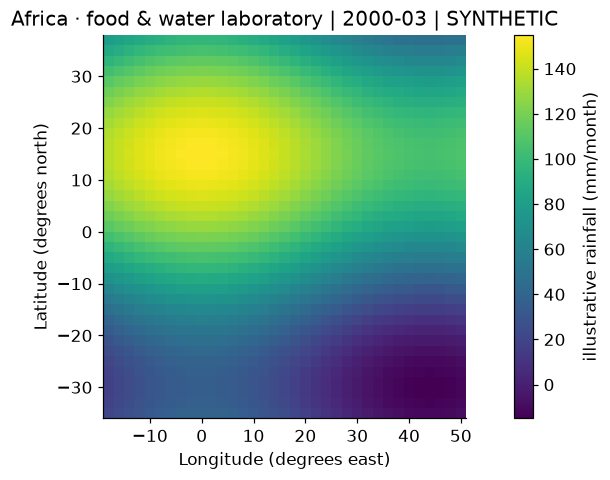

In [2]:
meta,rain=load_cube('rain')
map_slice(meta,rain,2);plt.show()

## 2. Use a reference with the same seasonal definition

Only one fictional year is present, so a climatological anomaly or SPI cannot be calculated.
Subtracting this field’s own annual mean produces a seasonal departure, not a climate anomaly or drought index.

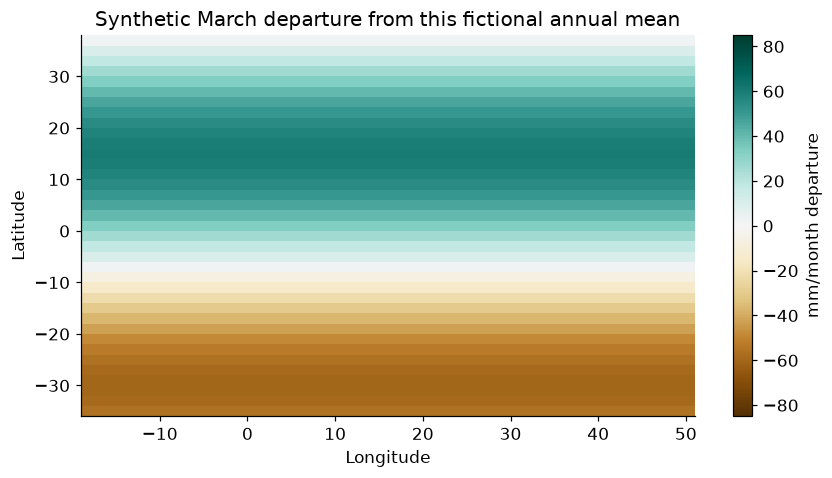

In [3]:
departures=rain-rain.mean(axis=0,keepdims=True)
fig,ax=plt.subplots()
image=ax.pcolormesh(meta['lon'],meta['lat'],departures[2],cmap='BrBG',vmin=-85,vmax=85,shading='nearest')
ax.set(xlabel='Longitude',ylabel='Latitude',title='Synthetic March departure from this fictional annual mean')
fig.colorbar(image,ax=ax,label='mm/month departure');plt.show()

## 3. Ask a portable SQL question

Count low-rainfall cell-months by latitude band. Explain the chosen threshold and the rectangle’s spatial support.
For a real extension, DE Africa provides access to rainfall and vegetation data; check each product’s native units, time axis, and license before use.

In [4]:
con=sql_connection(meta,rain)
query='SELECT t, COUNT(*) FROM cells WHERE value < 40 AND lat BETWEEN -15 AND 0 GROUP BY t ORDER BY t'
print(list(con.execute(query)))
lab('rain','cube')

[(2, 42), (3, 123), (4, 221), (5, 268), (6, 210), (7, 112), (8, 32)]


## 4. Construct an evidence ladder

**Observed physical variable → validated agronomic relationship → exposure and livelihoods → food-security assessment.**
At each arrow write down one missing dataset and one assumption. Include an adaptation option that local partners can evaluate,
such as forecast communication or water management, without claiming this notebook establishes its effectiveness.

## Try it yourself

Design a follow-on experiment joining real seasonal rainfall and vegetation. Specify a multi-year baseline and a validation strategy.

## Check your reasoning

Match spatial support and time intervals first. A correlation is not a causal effect, and a physical proxy alone is not a social vulnerability measure.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.
- [Digital Earth Africa datasets](https://docs.digitalearthafrica.org/en/latest/data_specs/index.html)

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.